-Know how to apply the **CART DECISION TREE** classifier to **image datasets**.

-Understand how the value of k impacts classifier performance.

-Be able to recognize handwritten digits from (a sample of) the **MNIST dataset**.

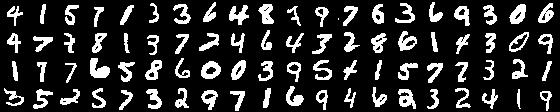

We are using the k-Nearest Neighbor classifier to classify images from the MNIST dataset, which consists of **handwritten digits**. 

The MNIST dataset is one of the most well studied datasets in the computer vision and machine learning literature. 

It’s a benchmark and a standard to which machine learning algorithms are ranked.

The goal of this dataset is to correctly classify the handwritten digits 0-9.

 Instead of utilizing the entire dataset (which consists of 60,000 training images and 10,000 testing images,) we’ll be using a small subset of the data provided by the scikit-learn library — this subset includes 1,797 digits, which we’ll split into **training**, **validation**, and **testing sets**, respectively.

In [ ]:
# import the necessary packages
from __future__ import print_function
from sklearn.datasets import fetch_openml
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn import datasets
from skimage import exposure
import numpy as np
import imutils
import cv2
import sklearn
import matplotlib.pyplot as plt

In [ ]:
mnist = fetch_openml('mnist_784', cache=False)




In [ ]:
mnist.data.shape

In [ ]:
# take the MNIST data and construct the training and testing split, using 75% of the
# data for training and 25% for testing
from sklearn.model_selection import train_test_split
(trainData, testData, trainLabels, testLabels) = train_test_split(np.array(mnist.data),
	mnist.target, test_size=0.1, random_state=42)



In [ ]:
# now, let's take 10% of the training data and use that for validation
(trainData, valData, trainLabels, valLabels) = train_test_split(trainData, trainLabels,
	test_size=0.1, random_state=84)

In [ ]:
# show the sizes of each data split
print("training data points: {}".format(len(trainLabels)))
print("validating data points: {}".format(len(valLabels)))
print("testing data points: {}".format(len(testLabels)))

In [ ]:
import seaborn as sns
sns.countplot(trainLabels)
plt.show()

print (trainLabels.value_counts())

In [ ]:
def plot_example(X, y):
    """Plot the first 5 images and their labels in a row."""
    for i, (img, y) in enumerate(zip(X[:5].reshape(5, 28, 28), y[:5])):
        plt.subplot(151 + i)
        plt.imshow(img)
        plt.xticks([])
        plt.yticks([])
        plt.title(y)

In [ ]:
import matplotlib.pyplot as plt
plot_example(trainData, trainLabels)

In [ ]:
from sklearn.tree import DecisionTreeClassifier 
#CART decision tree
dtree = DecisionTreeClassifier(criterion='gini')
dtree.fit(trainData , trainLabels)



In [ ]:

predictions = dtree.predict(valData)

# show a final classification report demonstrating the accuracy of the classifier
# for each of the digits
print("EVALUATION ON TESTING DATA")
print(classification_report(valLabels, predictions))

In [ ]:
from sklearn.metrics import confusion_matrix
ypred = dtree.predict(valData)
cmdtree = confusion_matrix(valLabels,ypred)
acc=dtree.score(valData , valLabels)*100
print("TEST ACCURACY=", acc)
cmdtree , acc
#print("TEST ACCURACY=", dtree.score(valData , valLabels)*100)

In [ ]:
from google.colab.patches import cv2_imshow
# loop over a few random digits
for i in list(map(int, np.random.randint(0, high=len(testLabels), size=(10,)))):
	# grab the image and classify it
	image = testData[i]
	prediction = dtree.predict(image.reshape(1, -1))[0]

	
	# then resize it to 28 x 28 pixels so we can see it better
	image = image.reshape((28, 28)).astype("uint8")
	image = exposure.rescale_intensity(image, out_range=(0, 255))
	image = imutils.resize(image, width=32, inter=cv2.INTER_CUBIC)

	# show the prediction
	print("Predicted digit is: {}".format(prediction))
	cv2_imshow(image)
	cv2.waitKey(0)

In [ ]:
from sklearn import tree
tree.plot_tree(dtree)